Architecture: (32,), Activation: tanh, Test MSE: 0.2901
Architecture: (32,), Activation: relu, Test MSE: 0.2901
Architecture: (32,), Activation: logistic, Test MSE: 0.2942
Architecture: (64,), Activation: tanh, Test MSE: 0.2943
Architecture: (64,), Activation: relu, Test MSE: 0.2913
Architecture: (64,), Activation: logistic, Test MSE: 0.2911
Architecture: (64, 32), Activation: tanh, Test MSE: 0.2464
Architecture: (64, 32), Activation: relu, Test MSE: 0.2587
Architecture: (64, 32), Activation: logistic, Test MSE: 0.2721
Architecture: (128, 64), Activation: tanh, Test MSE: 0.2579
Architecture: (128, 64), Activation: relu, Test MSE: 0.2491
Architecture: (128, 64), Activation: logistic, Test MSE: 0.2583
Architecture: (128, 64, 32), Activation: tanh, Test MSE: 0.2867
Architecture: (128, 64, 32), Activation: relu, Test MSE: 0.2676
Architecture: (128, 64, 32), Activation: logistic, Test MSE: 0.2599

=== Test MSE Table ===
Activation     logistic      relu      tanh
Architecture               

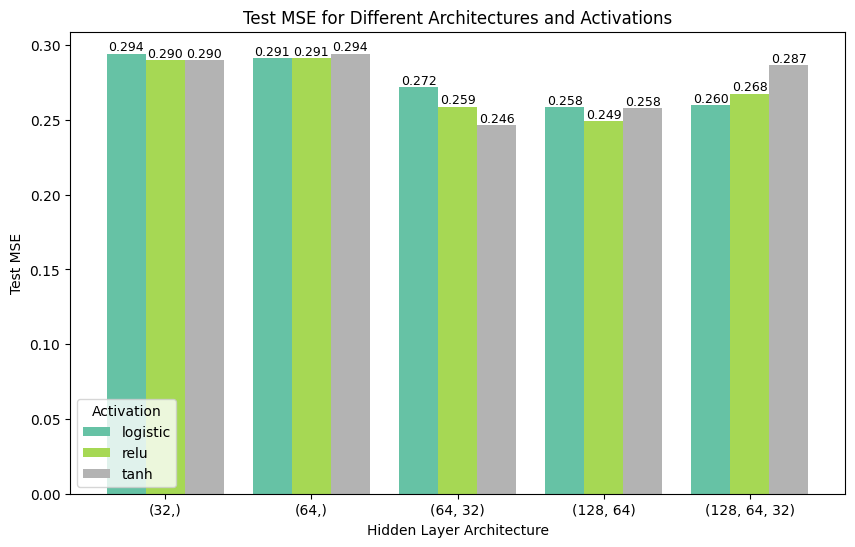

In [2]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Load and preprocess data
# 1) 加载并预处理数据
# ============================================================


# Load the California Housing dataset from sklearn.

# 从 sklearn 加载加州房价数据集

data = fetch_california_housing()


# Convert the feature matrix to a pandas DataFrame for easier manipulation.

# 将特征矩阵转换为 DataFrame，方便后续数据处理

X = pd.DataFrame(data.data, columns=data.feature_names)


# Convert target values (house prices) to a pandas Series.

# 将房价目标值转换为 Series

y = pd.Series(data.target, name="MedHouseVal")


# ------------------------------------------------------------
# Remove missing values
# 删除缺失值
# ------------------------------------------------------------


# Remove rows containing missing values to ensure clean training data.

# 删除包含缺失值的行，保证训练数据干净

X = X.dropna()
y = y.loc[X.index]


# ------------------------------------------------------------
# Split dataset into train / validation / test
# 数据集划分：训练集 / 验证集 / 测试集
# ------------------------------------------------------------


# First split data into training+validation (80%) and test set (20%).

# 先将数据划分为训练+验证集（80%）和测试集（20%）

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)

# Then split training+validation into actual training (72%) and validation (8%).

# 再将训练+验证集划分为训练集（72%）和验证集（8%）

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)


# ------------------------------------------------------------
# Standardize features
# 特征标准化
# ------------------------------------------------------------

# 
# Standardization rescales features so they have mean = 0 and std = 1.
# This helps neural networks train more efficiently.
# Important: fit only on the training set to avoid data leakage.
#
# 
# 标准化会让每个特征变成均值0、标准差1，
# 这样神经网络训练会更稳定、更快收敛。
# 注意：只在训练集上 fit，避免数据泄漏。

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=X.columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)


# ============================================================
# 2) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================


# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#

# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32,),
    (64,),
    (64,32),
    (128,64),
    (128,64,32)
]


# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
#

# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数

activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 3) Train models and collect Test MSE
#  训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model_test_act = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=700,
            random_state=26
        )

        
        # Train the model on the training dataset.
    
        # 在训练集上训练模型

        model_test_act.fit(X_train, y_train)

      
        # Predict house prices on the test set.
      
        # 在测试集上进行预测

        test_pred_act = model_test_act.predict(X_test)

        
        # Compute Mean Squared Error (MSE).
        # Lower MSE indicates better prediction performance.
       
        # 计算均方误差（MSE）。
        # MSE 越小，模型预测效果越好。

        test_mse_act = mean_squared_error(y_test, test_pred_act)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Test_MSE': test_mse_act
        })

        print(f"Architecture: {arch}, Activation: {act}, Test MSE: {test_mse_act:.4f}")


# ============================================================
# 4) Convert results to DataFrame
#  将结果转换为表格
# ============================================================


# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Test_MSE'
)
# -------------------------------------------------
# Fix architecture order for plotting
# 按定义的顺序重新排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Test MSE Table ===")
print(pivot_table)


# ============================================================
# 5) Plot grouped bar chart
# 绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Test MSE for each
# architecture and activation combination.
#
# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Test MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Test MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Test MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------

for p in ax.patches:

  
    # Get bar height (MSE value)
    # 获取柱子的高度（MSE值）

    height = p.get_height()

   
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.show()

In [16]:
# model (no internal early stopping, since you already have X_val)
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=700,
    early_stopping=True,
    random_state=26
)

model.fit(X_train, y_train)
#测试集和预测集的预测
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# 训练集预测
train_pred = model.predict(X_train)
# 计算训练误差
train_mse = mean_squared_error(y_train, train_pred)

print("Baseline Train MSE:", train_mse)#加入是为了判断是不是欠拟合或者过拟合
print("Validation MSE:", mean_squared_error(y_val, val_pred))#Mean Squared Error（均方误差）
print("Test MSE:", mean_squared_error(y_test, test_pred))

Baseline Train MSE: 0.26190524338772764
Validation MSE: 0.3057820937943312
Test MSE: 0.2668096262952686


Search for Architecture and Activation Functions:

We conduct a grid search across various "hidden layer architectures" and "activation functions" to enhance the neural network model's performance.

About the Hidden Layer Architectures, there are numerous neural network architectures with varying neurons and layer counts that are examined, such as:
Network with a single hidden layer: (32,), (64,)
Network with two hidden layers: (64,32), (128,32), and
Network with three hidden layers (128,64,32)
The number of nerons in each hidden layer is represented by each tuple.
For instance, (64,32) indicates that the network has two hidden layers, with 32 neurones in the second layer and 64 neurones in the first.

There are three activation functions we have used:
One popular activation in deep learning is ReLU. 
Tanh is a nonlinear activation function that is symmetric. 
A traditional nonlinear activation function is the logistic(Sigmoid) function.

Model Evaluation:
The training dataset is used to train a neural network for every combination of architecture and activation function. Also, the Mean Squared Error (MSE) on the validation dataset is used to assess the model's performance. 
To compare the validation errors across various model settings, the results are saved in a table and displayed using a grouped bar chart.
 
According to the results, the model with architecture (128,32) and tanh activation function had the lowest validation MSE (0.2788).
As a result, the configuration is chosen as the neural network structure that performs the best for this task.





Architecture: (32,), Activation: tanh, Validation MSE: 0.3137
Architecture: (32,), Activation: relu, Validation MSE: 0.3262
Architecture: (32,), Activation: logistic, Validation MSE: 0.3210
Architecture: (64,), Activation: tanh, Validation MSE: 0.3140
Architecture: (64,), Activation: relu, Validation MSE: 0.3272
Architecture: (64,), Activation: logistic, Validation MSE: 0.3120
Architecture: (64, 32), Activation: tanh, Validation MSE: 0.2841
Architecture: (64, 32), Activation: relu, Validation MSE: 0.2890
Architecture: (64, 32), Activation: logistic, Validation MSE: 0.3078
Architecture: (128, 32), Activation: tanh, Validation MSE: 0.2789
Architecture: (128, 32), Activation: relu, Validation MSE: 0.2775
Architecture: (128, 32), Activation: logistic, Validation MSE: 0.2899
Architecture: (128, 64), Activation: tanh, Validation MSE: 0.2798
Architecture: (128, 64), Activation: relu, Validation MSE: 0.2793
Architecture: (128, 64), Activation: logistic, Validation MSE: 0.2855
Architecture: (12

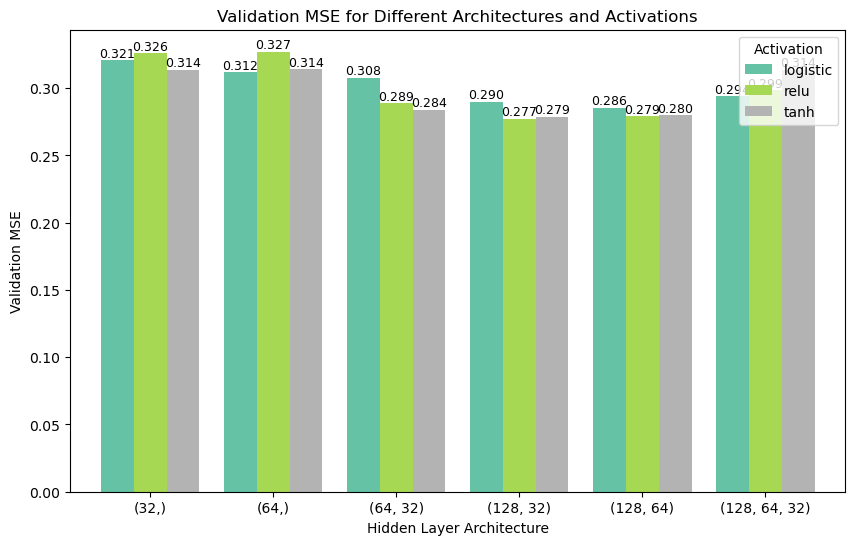

In [8]:
import matplotlib.pyplot as plt
# 1) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================

# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32,),
    (64,),
    (64,32),
    (128,32),
    (128,64),
    (128,64,32)
]

# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
#
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数

activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 2) Train models and collect Test MSE
# 训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        #
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model_test_act = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=800,
            n_iter_no_change = 10,
            early_stopping=False,
            random_state=26
        )
        #Adding n_iter_no_change can slightly speed up training because it affects the internal 
        #convergence checks, causing the optimizer to stabilize faster even without early stopping.
        #添加n_iter_no_change 会稍微加快训练，因为它影响了内部收敛检查
        # 使优化器即使在不使用 early stopping 的情况下也能更快稳定。

        #Adding n_iter_no_change can slightly speed up training because it affects the internal 
        #convergence checks, causing the optimizer to stabilize faster even without early stopping.
        #添加n_iter_no_change 会稍微加快训练，因为它影响了内部收敛检查
        # 使优化器即使在不使用 early stopping 的情况下也能更快稳定。
        # Train the model on the training dataset.
        # 在训练集上训练模型

        model_test_act.fit(X_train, y_train)

        
        # Predict house prices on the validation set
        # 在验证集上进行预测

        val_pred_act = model_test_act.predict(X_val)

        # Compute Mean Squared Error (MSE) on validation set
        # 计算验证集上的均方误差

        val_mse_act = mean_squared_error(y_val, val_pred_act)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Validation_MSE': val_mse_act
        })

        print(f"Architecture: {arch}, Activation: {act}, Validation MSE: {val_mse_act:.4f}")

# ============================================================
# 3) Convert results to DataFrame
# 将结果转换为表格
# ============================================================

# 
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
#

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Validation_MSE'
)

# -------------------------------------------------
# Fix architecture order for plotting
# 按定义的顺序重新排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 32)','(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Validation MSE Table ===")
print(pivot_table)


# ============================================================
# 4) Plot grouped bar chart
#  绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Validation MSE for each
# architecture and activation combination.
#

# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Validation MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Validation MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Validation MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------

for p in ax.patches:


    # Get bar height (MSE value)
    # 获取柱子的高度（MSE值）

    height = p.get_height()

  
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值





# Add value labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)
Architecture: (32,), Activation: tanh, Validation MSE: 0.3137
Architecture: (32,), Activation: relu, Validation MSE: 0.3

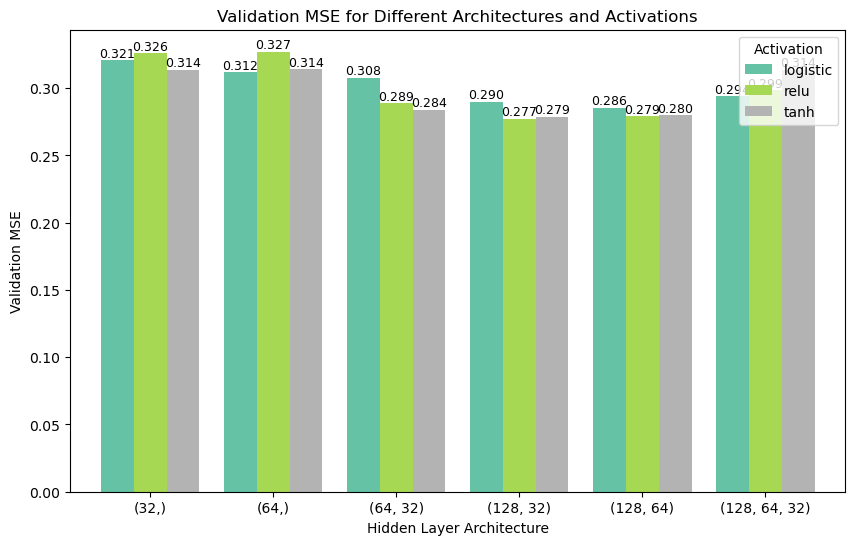

Final Baseline Train MSE: 0.23981524417887298
Final Baseline Test MSE: 0.24851482842267858


,combo_name,num_features,val_mse
0,Mean,1,0.211151
1,Median,1,0.215764
2,Max,1,0.231737
3,Min,1,0.252567
4,Range,1,0.283264
5,Median + Range,2,0.217884
6,Median + Max,2,0.219297
7,Mean + Max,2,0.219599
8,Median + Min,2,0.220907
9,Mean + Median,2,0.222763


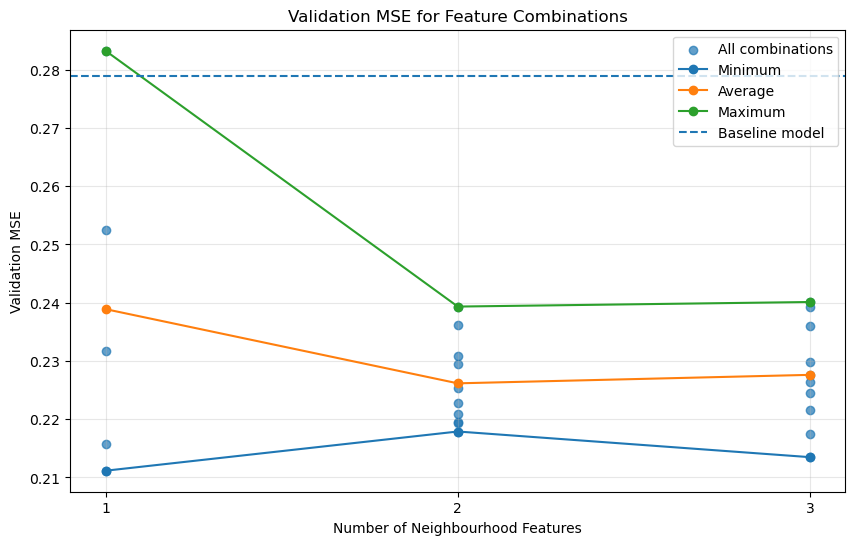

     k feature   val_mse
0    3    Mean  0.226609
1    3  Median  0.216555
2    3     Min  0.247268
3    3     Max  0.229717
4    3   Range  0.274513
5    5    Mean  0.219090
6    5  Median  0.214479
7    5     Min  0.257406
8    5     Max  0.232713
9    5   Range  0.282690
10   7    Mean  0.215793
11   7  Median  0.221719
12   7     Min  0.254429
13   7     Max  0.227578
14   7   Range  0.272400
15  10    Mean  0.210448
16  10  Median  0.213539
17  10     Min  0.252699
18  10     Max  0.241687
19  10   Range  0.279295
20  15    Mean  0.218665
21  15  Median  0.215143
22  15     Min  0.266340
23  15     Max  0.246745
24  15   Range  0.270083


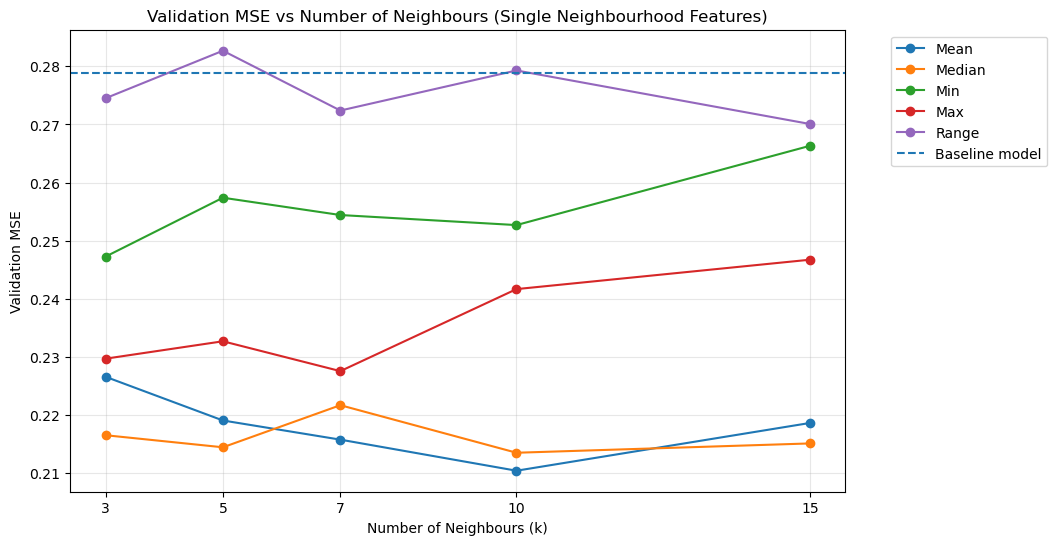

Final Baseline Test MSE: 0.24851482842267858
Final Enhanced Test MSE: 0.18047048234110835
Delta Test MSE (Enhanced - Baseline): -0.06804434608157023

Model 1 — Baseline (validation stage)
Train MSE             : 0.2235
Validation MSE        : 0.2789
Validation/Train Ratio: 1.248
Diagnosis: moderate generalisation gap / reasonable fit

Model 2 — Enhanced (validation stage)
Train MSE             : 0.1530
Validation MSE        : 0.2104
Validation/Train Ratio: 1.376
Diagnosis: moderate generalisation gap / reasonable fit


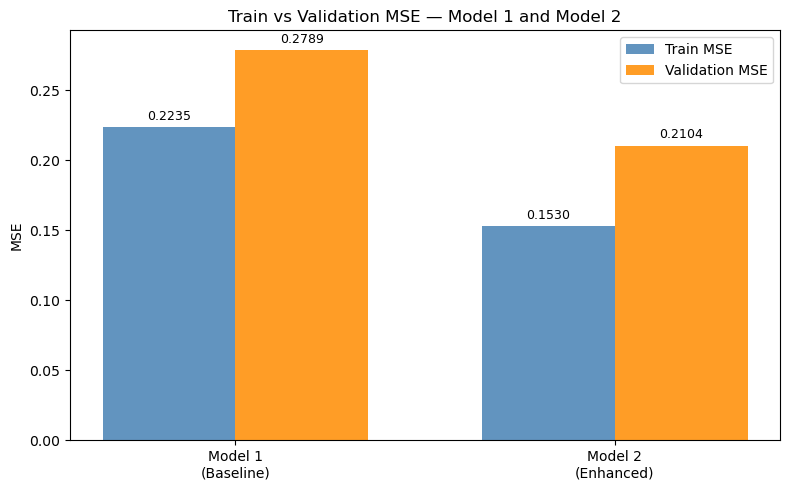

Model 1 actual training epochs: 306
Model 2 actual training epochs: 251
Note: fewer epochs than max_iter indicate optimiser convergence before max_iter.


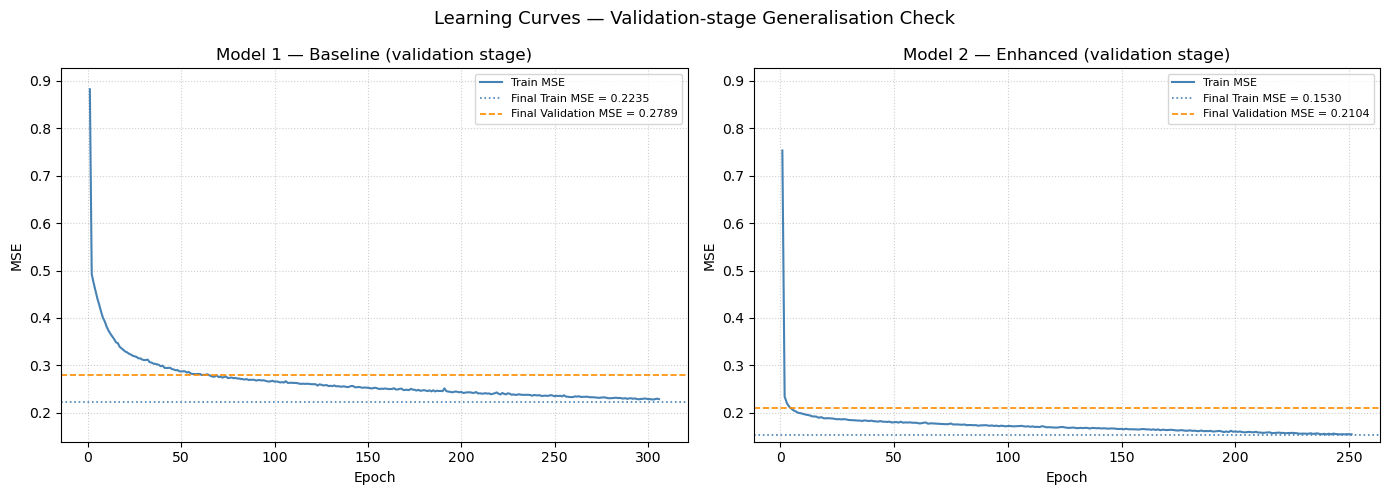


=== Improvement Analysis ===
Baseline Test MSE: 0.2485
Best Enhanced Test MSE: 0.1805
Improvement Percentage: 27.38%


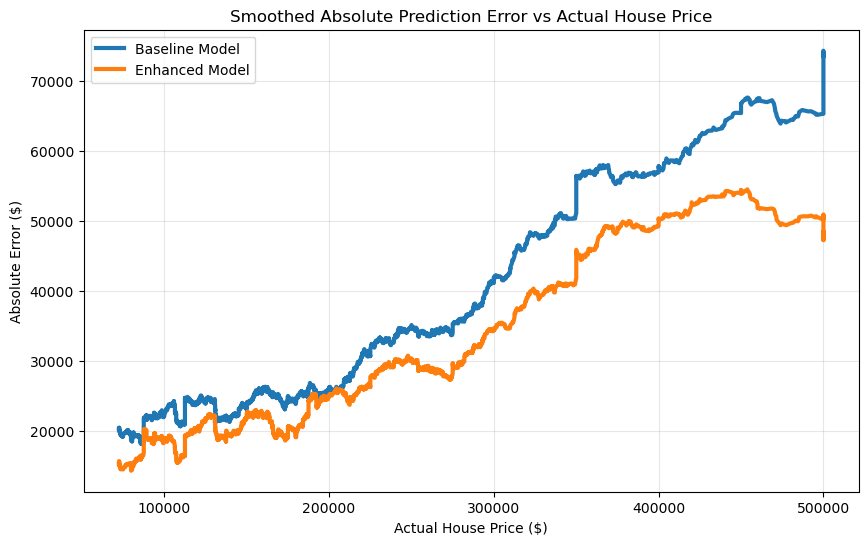

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


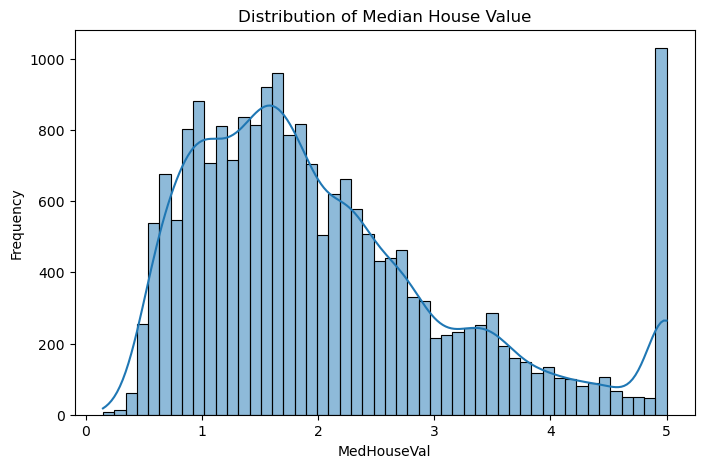

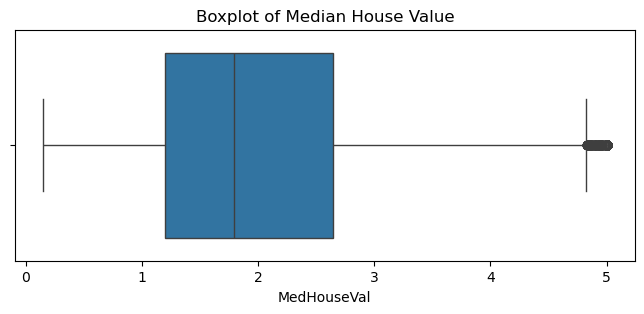

Top 10 highest house values:
10667    5.00001
16916    5.00001
16946    5.00001
8877     5.00001
8878     5.00001
8879     5.00001
16941    5.00001
16940    5.00001
16939    5.00001
16938    5.00001
Name: MedHouseVal, dtype: float64
Number of unique coordinates: 12590
Number of duplicated coordinate locations: 4353
Top duplicated coordinates:
      Longitude  Latitude  count
936     -122.41     37.80     15
907     -122.42     37.80     11
865     -122.44     37.78     11
883     -122.43     37.77     10
902     -122.42     37.75     10
1310    -122.27     37.85     10
931     -122.41     37.75     10
866     -122.44     37.79     10
867     -122.44     37.80     10
881     -122.43     37.75     10


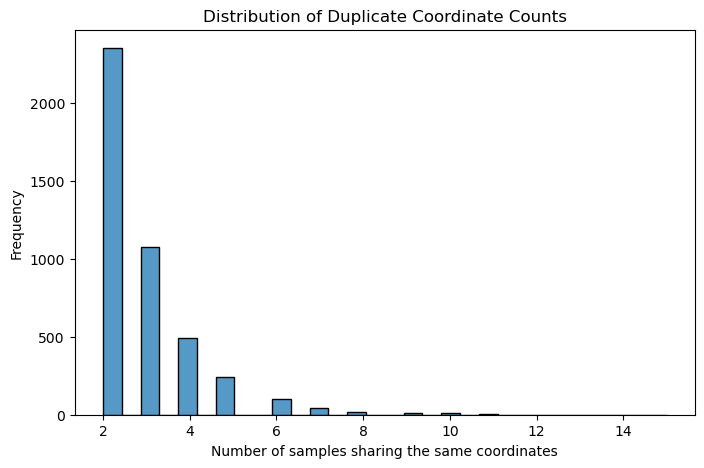

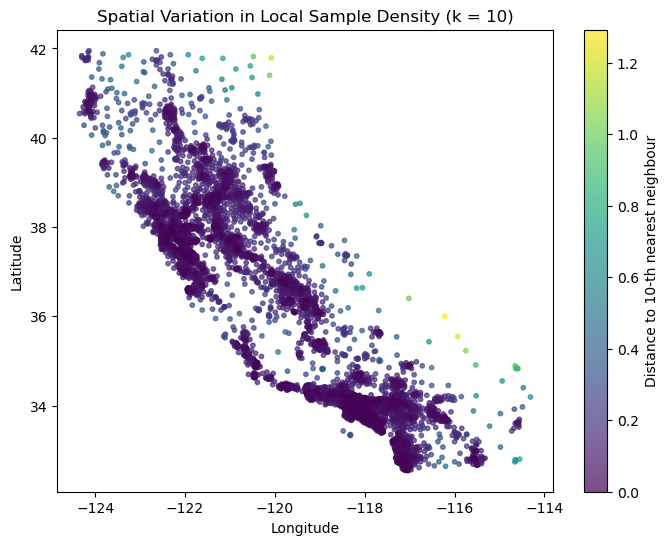

In [2]:
%run main.ipynb

In [3]:
print(baseline_val_mse)

0.2788722368528284


Search for the Best Architecture and Activation Functions

We conduct a grid search across various "hidden layer architectures" and "activation functions" to enhance the neural network model's performance.

Hidden Layer Architectures:

We consider seveal neural network architectures with varying numbers of neurons and layers

- Single hidden layer: (32,) and (64,)
- Two hidden layers: (64,32) and (128,32)
- Three hidden layers: (128,64,32)

The number of neurons in each hidden layer is represented by each tuple.


There are three activation functions we have used:

- ReLU (a popular activation in deep learning)
- tanh (a symmetric nonlinear activation function) 
- logistic (Sigmoid) (a traditional nonlinear activation function)

Evaluation method:

For each combination, the model is trained on the training set and evaluated using Mean Squared Error (MSE) on the validation set.

The bar chart shows the validation MSE for each architecture and activation function.
According to the results, the architecture (128,32) with tanh achieves the lowest validation MSE - around 0.2788.
Therefore, (128,32) with tanh is selected as the optimal model configuration.





Actual Home Price vs. Absolute Error

This section compares the prediction performance of the Baseline Model and the Enhanced Model.

The x-axis represents the actual house price, while the y-axis represents the absolute prediction error, which is defined as: $|Prediction - Actual| 

The California Housing dataset was used in this investigation.
Since property prices in this dataset are expressed in units of $100,000, all values are converted to actual dollar prices by multiplying them by 100,000.

A rolling average smoothing approach with a window size of 300 observations is used to better visualise the overall trend.  

The figure shows the absolute prediction error of both models across a range of home prices.

In general, the Enhanced Model produces lower errors than the Baseline Model, especially for more expensive houses.

This suggests that for most price ranges, the Enhanced Model provides more accurate forecasts.



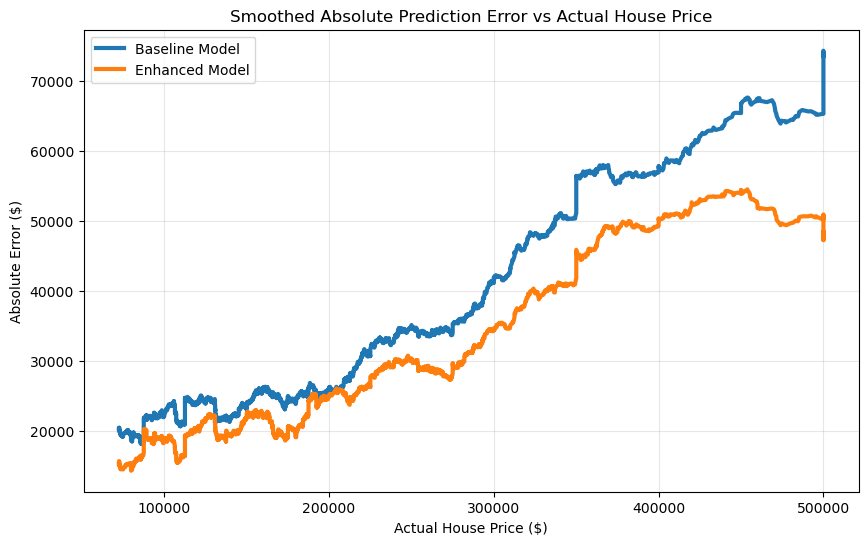

In [9]:

# ============================================================
# Absolute Error vs Actual House Price 
# Baseline Model vs Enhanced Model
# ============================================================
# 图像说明：
# x轴：真实房价 (单位：美元 $)
# y轴：绝对误差 |Prediction - Actual| (单位：美元 $)
# California Housing 数据集中的房价单位是 10 万美元
# 因此需要乘以 100000 转换为真实美元价格
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extract actual house prices
# 提取真实房价
# 数据集中房价单位是 100,000 美元
# 因此需要乘以 100000 转换为真实美元
# ------------------------------------------------------------

actual_price = y_test.to_numpy() * 100000


# ------------------------------------------------------------
# 2. Convert predictions to dollars
# 将模型预测值也转换为美元单位
# ------------------------------------------------------------

baseline_pred_dollar = baseline_test_pred * 100000
enhanced_pred_dollar = test_pred_enh_final * 100000


# ------------------------------------------------------------
# 3. Compute absolute errors
# 计算绝对误差 |prediction - actual|
# ------------------------------------------------------------

baseline_abs_error = np.abs(baseline_pred_dollar - actual_price)
enhanced_abs_error = np.abs(enhanced_pred_dollar - actual_price)


# ------------------------------------------------------------
# 4. Build dataframe for sorting
# 构建 dataframe 并按真实房价排序
# ------------------------------------------------------------

df_plot = pd.DataFrame({
    "ActualPrice": actual_price,
    "BaselineError": baseline_abs_error,
    "EnhancedError": enhanced_abs_error
})

df_plot = df_plot.sort_values("ActualPrice")


# ------------------------------------------------------------
# 5. Rolling average smoothing
# 滚动平均平滑曲线
# ------------------------------------------------------------

window = 300
# window = 300 means each rolling average uses the current point
# and the previous 299 observations (300 points in total)
# window = 300 表示每个滚动平均使用当前点和前面 299 个数据
# 一共 300 个点来计算平均值

baseline_smooth = df_plot["BaselineError"].rolling(window=300).mean()
enhanced_smooth = df_plot["EnhancedError"].rolling(window=300).mean()


# ------------------------------------------------------------
# # 6. Plot smoothed trends
# 繪製平滑趨勢線
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(
    df_plot["ActualPrice"],
    baseline_smooth,
    linewidth=3,
    label="Baseline Model"
)

plt.plot(
    df_plot["ActualPrice"],
    enhanced_smooth,
    linewidth=3,
    label="Enhanced Model"
)


# ------------------------------------------------------------
# 7. Formatting
# 图像设置
# ------------------------------------------------------------

plt.xlabel("Actual House Price ($)")
plt.ylabel("Absolute Error ($)")
plt.title("Smoothed Absolute Prediction Error vs Actual House Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



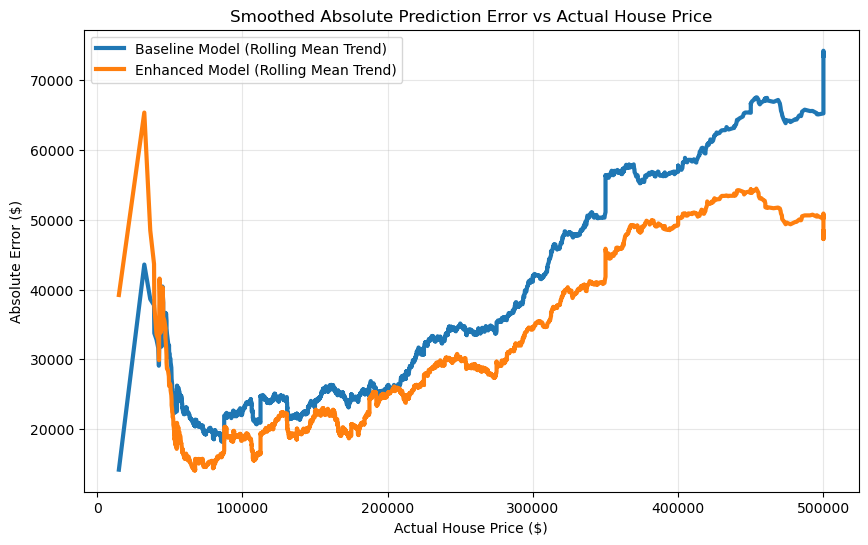

In [6]:

# ============================================================
# Absolute Error vs Actual House Price 
# Baseline Model vs Enhanced Model
# ============================================================
# 图像说明：
# x轴：真实房价 (单位：美元 $)
# y轴：绝对误差 |Prediction - Actual| (单位：美元 $)
# California Housing 数据集中的房价单位是 10 万美元
# 因此需要乘以 100000 转换为真实美元价格
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extract actual house prices
# 提取真实房价
# 数据集中房价单位是 100,000 美元
# 因此需要乘以 100000 转换为真实美元
# ------------------------------------------------------------


actual_price = y_test.to_numpy() * 100000


# ------------------------------------------------------------
# 2. Convert predictions to dollars
# 将预测值也转换为美元
# ------------------------------------------------------------

baseline_pred_dollar = baseline_test_pred * 100000
enhanced_pred_dollar = test_pred_enh_final * 100000


# ------------------------------------------------------------
# 3. Compute absolute errors
# 计算绝对误差
# ------------------------------------------------------------

baseline_abs_error = np.abs(baseline_pred_dollar - actual_price)
enhanced_abs_error = np.abs(enhanced_pred_dollar - actual_price)


# ------------------------------------------------------------
# 4. Build dataframe and sort by price
# 构建 dataframe 并按房价排序
# ------------------------------------------------------------

df_plot = pd.DataFrame({
    "ActualPrice": actual_price,
    "BaselineError": baseline_abs_error,
    "EnhancedError": enhanced_abs_error
})

df_plot = df_plot.sort_values("ActualPrice")


# ------------------------------------------------------------
# 5. Rolling average smoothing
# 滚动平均平滑曲线
# ------------------------------------------------------------

window = 300
# window = 300 means each rolling average uses the current point
# and the previous 299 observations (300 points in total)
# window = 300 表示每个滚动平均使用当前点和前面 299 个数据
# 一共 300 个点来计算平均值

baseline_trend = df_plot["BaselineError"].rolling(window=300, min_periods=1).mean()
enhanced_trend = df_plot["EnhancedError"].rolling(window=300, min_periods=1).mean()


# ------------------------------------------------------------
# 6. Plot smoothed trends
# 绘制平滑趋势
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(
    df_plot["ActualPrice"],
    baseline_trend,
    linewidth=3,
    label="Baseline Model (Rolling Mean Trend)"
)

plt.plot(
    df_plot["ActualPrice"],
    enhanced_trend,
    linewidth=3,
    label="Enhanced Model (Rolling Mean Trend)"
)


# ------------------------------------------------------------
# 7. Formatting
# 图像设置
# ------------------------------------------------------------

plt.xlabel("Actual House Price ($)")
plt.ylabel("Absolute Error ($)")
plt.title("Smoothed Absolute Prediction Error vs Actual House Price")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()




